In [1]:
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')

In [6]:
datos_penguins.shape

(344, 7)

Tenemos 344 filas, y 7 caracteristicas

In [7]:
datos_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


Tenemos 7 categorias, 4 numericas y 3 categoricas.

In [8]:
datos_penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Tenemos pocos nulos, los cuales, para este analisis, los voy a eliminar, y no los voy a tener en cuenta.

In [ ]:
datos_penguins = datos_penguins.dropna()

#### ¿Que es este dataset? 

Palmerpenguins sale en 2020, como alternativa de "dataset de juguete" a iris.
Son datos recolectados entre 2007 y 2009 (Columna existente, la cual falta en este dataset), por la Dra. Kristen Gorman, el cual contiene datos acerca de los datos de 344 pinguinos, tomados de 3 islas del archipielago Palmer, en la Antartida.

Son datos que hablan de:

In [ ]:
datos_penguins.species.unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

- Las 3 especies que se estudiaron en el dataset: En el mundo hay 18, y 7 de ellas viven en la antartida (https://www.asoc.org/learn/antarctic-penguins-directory/)

In [ ]:
datos_penguins.island.unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

- Estas son las 3 islas de las cuales se recabo informacion.

Ademas, vemos caracteristicas fisicas de los pinguinos
- Estan las columnas bill_lenght y bill_depth, que refieren al pico de los pinguinos

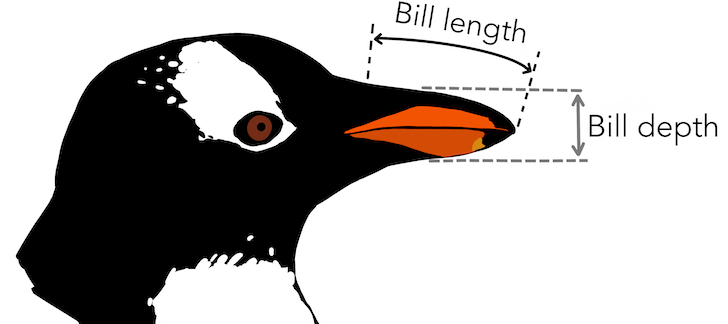

- La columna flipper_lengtH, que refiere al largo de la aleta

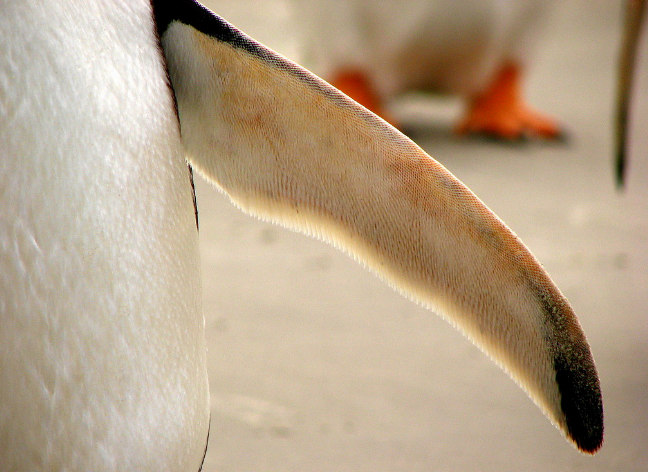

- y por ultimo, el peso del pinguino, y su sexo

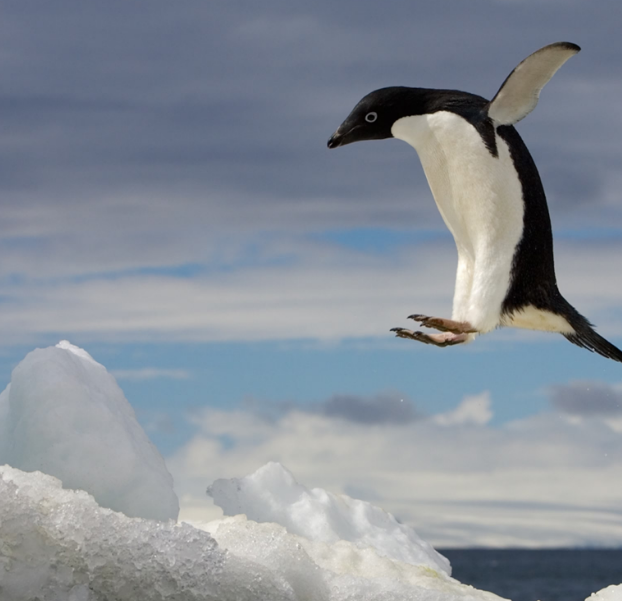

In [ ]:
datos_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
datos_penguins.median(numeric_only=True)

,0
bill_length_mm,44.5
bill_depth_mm,17.3
flipper_length_mm,197.0
body_mass_g,4050.0


In [ ]:
datos_penguins.mode()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Biscoe,41.1,17.0,190.0,3800.0,Male


Que preguntas me hago respecto a esto?
- Los pinguinos estan en todas las islas? O las especies residen en islas en particular?
- Hay diferencias en las cualidades fisicas entre los pinguinos femenino y masculino de las especies?
- Se relaciona en algo el lugar donde fueron tomadas las mediciones, con su tamaño?
- Los pinguinos, se mueven entre estas islas? Es decir, las mediciones, si hubieran sido tomadas al dia siguiente, puede un pinguino haber estado en otra de estas islas? O son inaccesibles entre si?

In [ ]:
categoricas = datos_penguins.select_dtypes(include=['object', 'category'])

In [ ]:
categoricas.value_counts()

species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Male      22
                      Female    22
Name: count, dtype: int64

Las razas Gento y Chinstrap aparecen en una sola isla. La raza Adelie es la unica que aparece en la isla Torgensen, por lo que es un buen atributo para identificar varios ejemplares.

Analisis de histograma

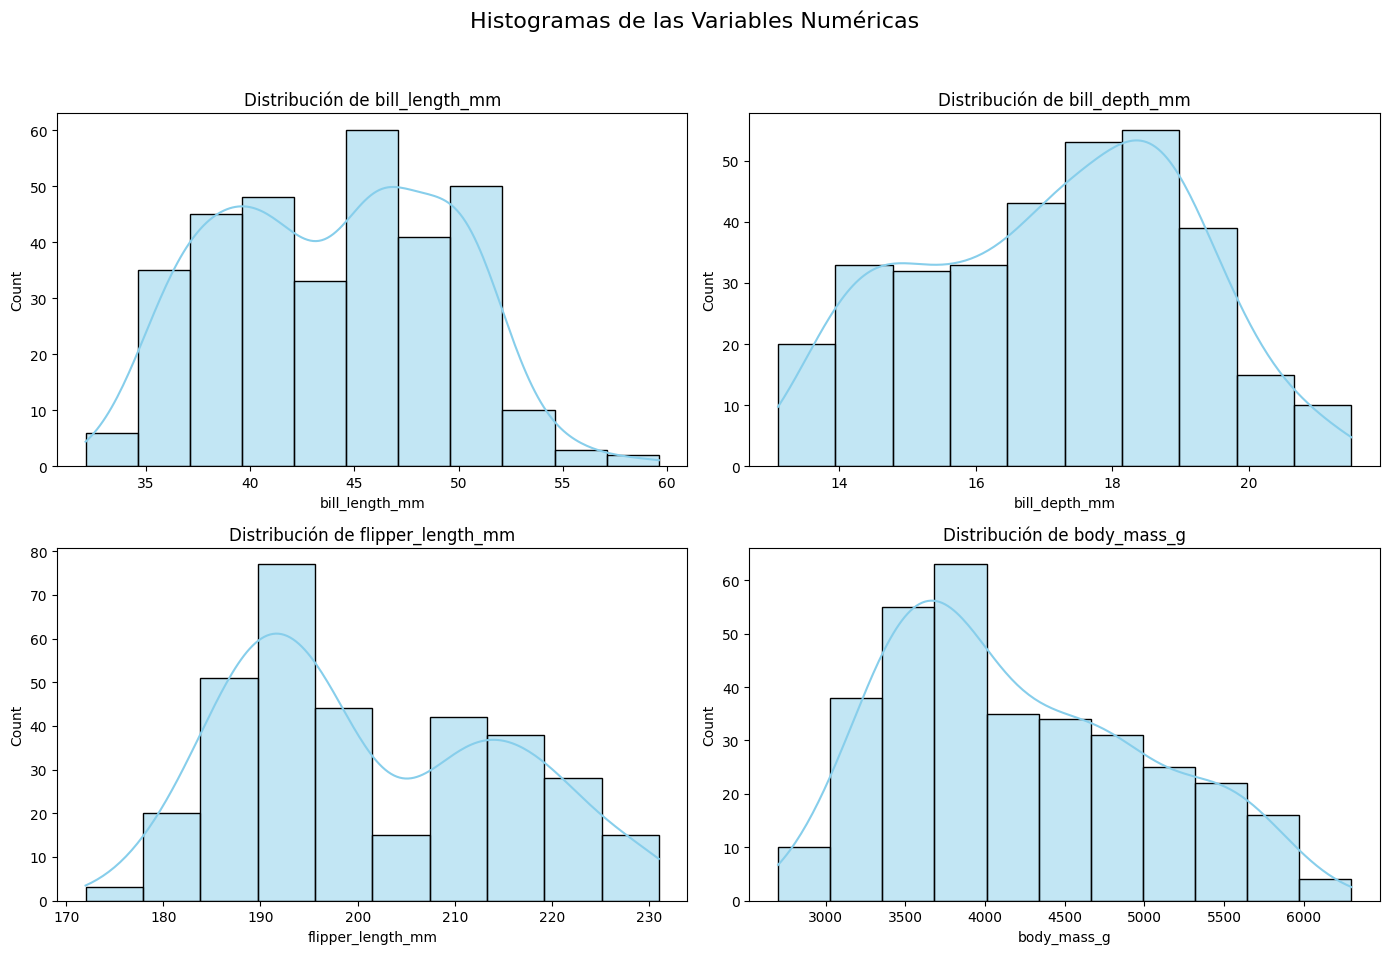

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos las columnas numéricas
columnas_numericas = datos_penguins.select_dtypes(include=['float64', 'int64']).columns

# Configuración de los histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogramas de las Variables Numéricas', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.histplot(datos_penguins[col], kde=True, ax=axes[i//2, i%2], color='skyblue')
    axes[i//2, i%2].set_title(f'Distribución de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

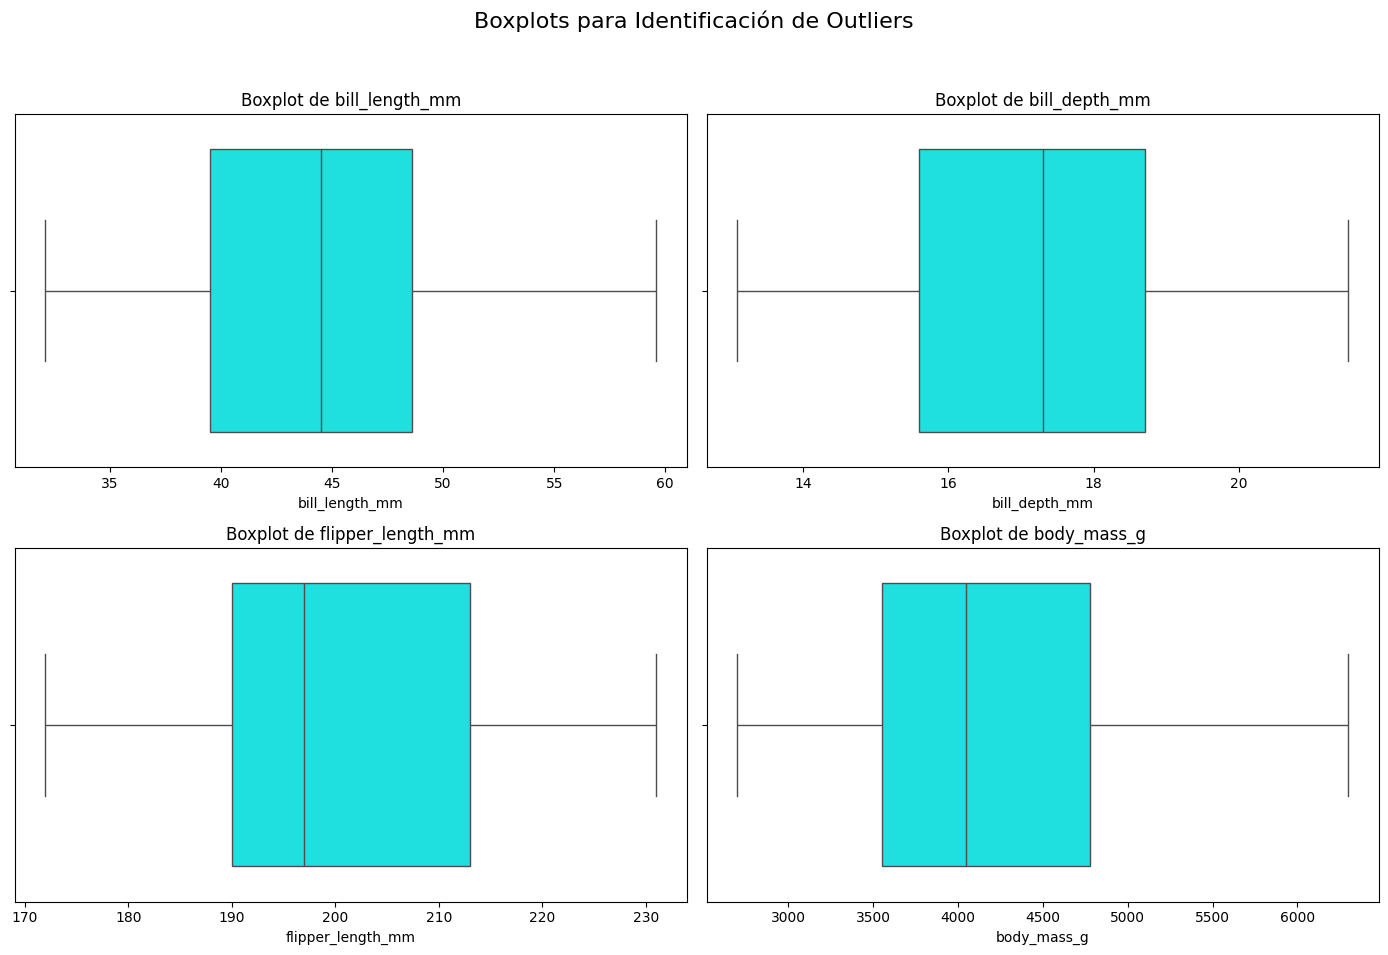

In [ ]:
# Configuración de los Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots para Identificación de Outliers', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=datos_penguins[col], ax=axes[i//2, i%2], color='cyan')
    axes[i//2, i%2].set_title(f'Boxplot de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

# Filtramos datos numéricos eliminando nulos para el cálculo preciso
datos_numericos = datos_penguins.select_dtypes(include=['float64', 'int64'])
stats_list = []
for col in datos_numericos.columns:
    stats_list.append({
        'Variable': col,
        'Asimetría (Skewness)': skew(datos_numericos[col]),
        'Curtosis (Kurtosis)': kurtosis(datos_numericos[col])
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats)

,Variable,Asimetría (Skewness),Curtosis (Kurtosis)
0,bill_length_mm,0.045136,-0.888173
1,bill_depth_mm,-0.149045,-0.896587
2,flipper_length_mm,0.358524,-0.964833
3,body_mass_g,0.470116,-0.740486


1. **bill_length_mm:** Asimetría cercana a 0 -> distribución relativamente balanceada.
2. **flipper_length_mm:** Curtosis negativa -> la distribución es más plana que una normal (platicúrtica).
3. **body_mass_g:** Asimetría positiva -> mayoría de los pingüinos tienen pesos bajos/medios, y hay pocos que son mucho más pesados.

###Ej. 2

Vamos a hacer un analisis de las variables numericas, pero segmentado por especie

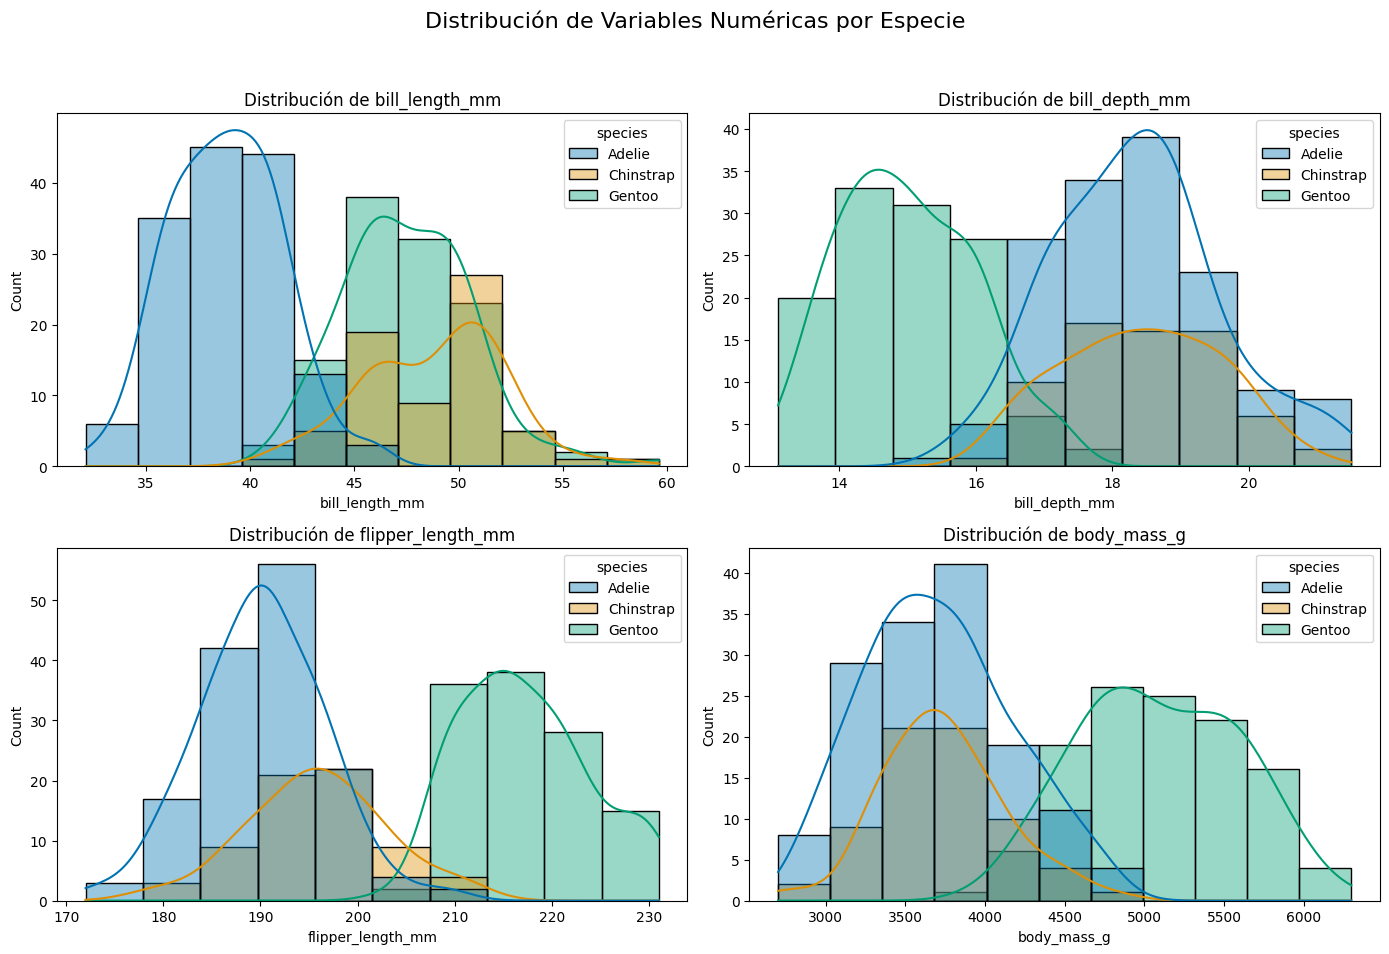

In [ ]:
# @title
# Histogramas segmentados por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.histplot(data=datos_penguins, x=col, hue='species', kde=True, ax=axes[i//2, i%2], palette='colorblind', alpha=0.4)
    axes[i//2, i%2].set_title(f'Distribución de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

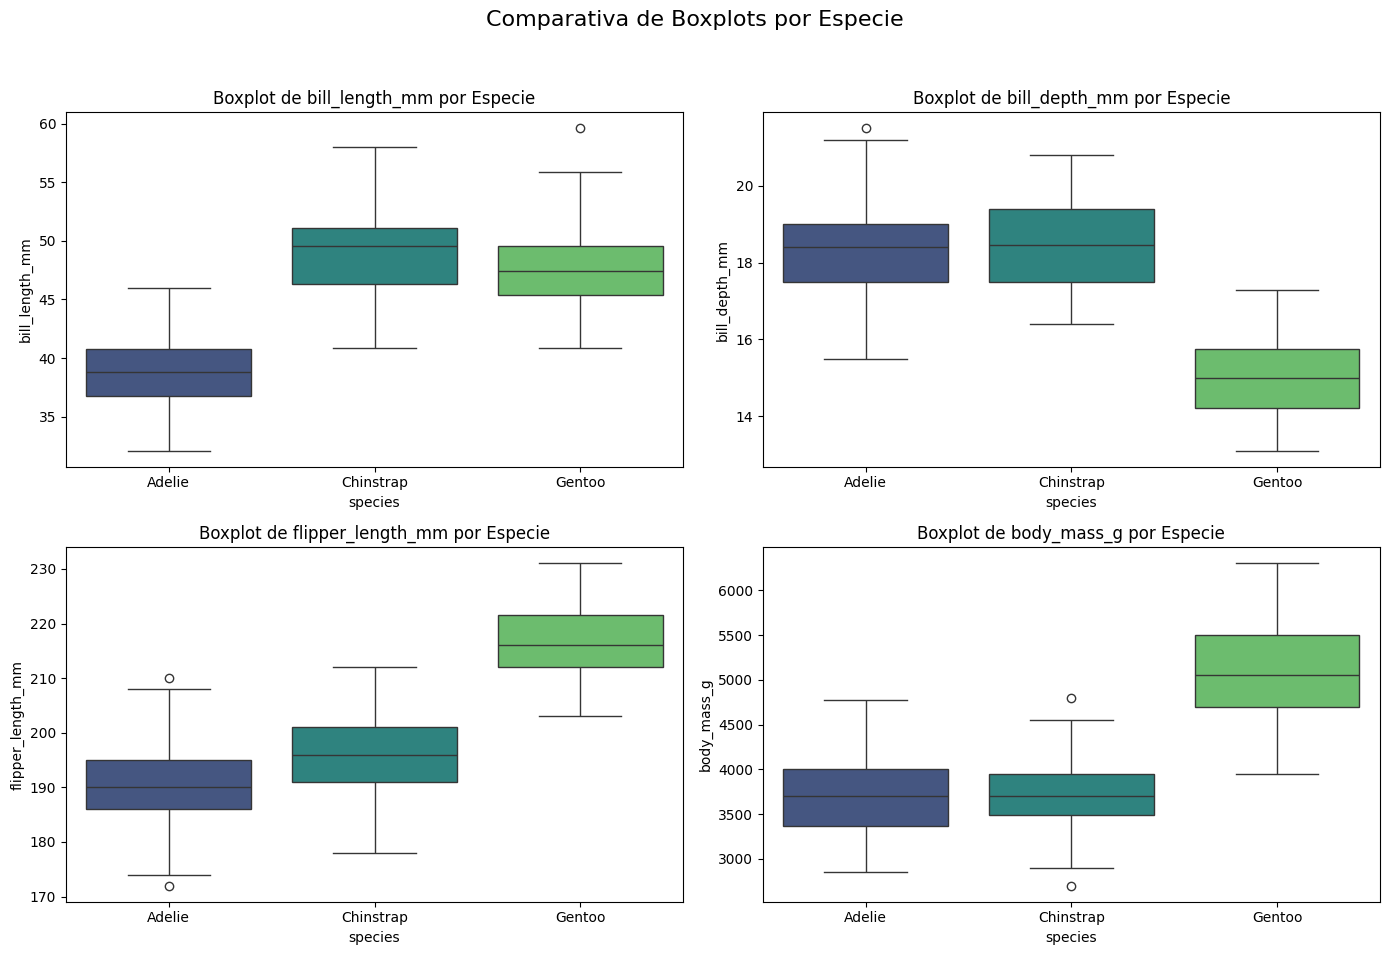

In [ ]:
# @title
# Boxplots segmentados por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Boxplots por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=datos_penguins, x='species', y=col, hue='species', ax=axes[i//2, i%2], palette='viridis', legend=False)
    axes[i//2, i%2].set_title(f'Boxplot de {col} por Especie')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Hagamos la tabla de contingencia

In [ ]:
import pandas as pd

# Crear tabla de contingencia entre especie e isla
tabla_especie_isla = pd.crosstab(datos_penguins['species'], datos_penguins['island'], margins=True)

print("Tabla de Contingencia: Especie vs Isla")
display(tabla_especie_isla)

Tabla de Contingencia: Especie vs Isla


island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,55,47,146
Chinstrap,0,68,0,68
Gentoo,119,0,0,119
All,163,123,47,333


In [ ]:
# También podemos ver la asociación entre especie y sexo
tabla_especie_sexo = pd.crosstab(datos_penguins['species'], datos_penguins['sex'])

print("\nTabla de Contingencia: Especie vs Sexo")
display(tabla_especie_sexo)


Tabla de Contingencia: Especie vs Sexo


sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


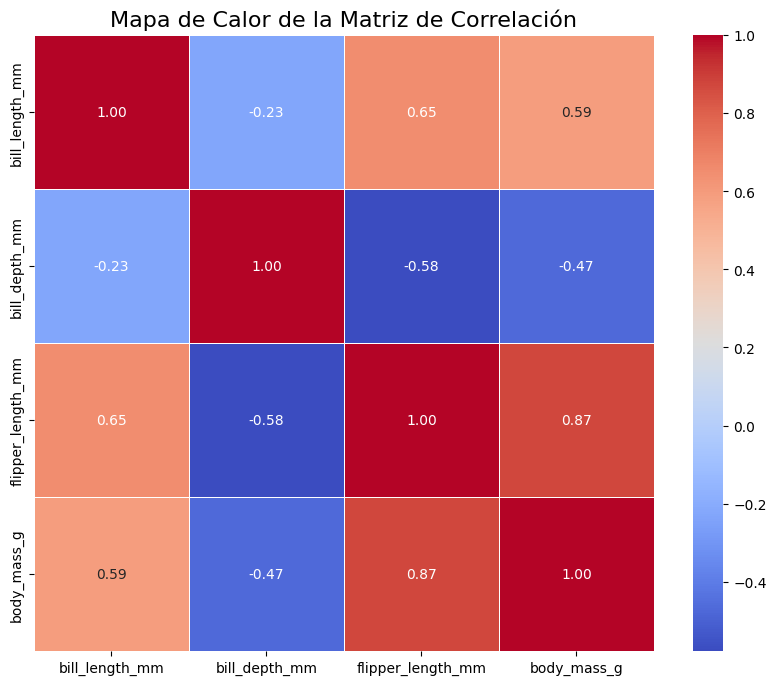

In [ ]:
# Calcular la matriz de correlación
matriz_corr = datos_penguins.select_dtypes(include=['float64', 'int64']).corr()

# Visualización con Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)
plt.show()